# The Skill Decay vs. Skill Augmentation Paradox
## Competitive Programming in the Age of AI: 2021 (Pre-AI) → 2025 (AI-Ubiquitous)

---


**Project Pipeline:**
1. Data Simulation & Scraping Template
2. Exploratory Data Analysis (EDA)
3. Machine Learning — AI-Assistance Prediction & User Segmentation
4. Statistical Testing
5. Executive Summary

**Dataset:** 10,000 synthetic submissions modeled on real-world Codeforces/LeetCode behavioral trends (2021–2025)

---
## Section 0 — Environment Setup & Library Imports

In [16]:
# ============================================================
# Install any missing libraries (run once if needed)
# ============================================================
# !pip install xgboost scikit-learn seaborn matplotlib pandas numpy scipy requests beautifulsoup4

import warnings
warnings.filterwarnings('ignore')

# --- Core Data Libraries ---
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Machine Learning ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# --- Statistical Testing ---
from scipy import stats

# --- Web Scraping (template) ---
import requests
from bs4 import BeautifulSoup
import time

# --- Global Style ---
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("✓ All libraries loaded successfully.")
print(f"  NumPy  : {np.__version__}")
print(f"  Pandas : {pd.__version__}")
print(f"  Seaborn: {sns.__version__}")

✓ All libraries loaded successfully.
  NumPy  : 1.26.4
  Pandas : 2.2.2
  Seaborn: 0.13.2


---
## Section 1 — Data Acquisition
### 1A. BeautifulSoup Scraping Template (Codeforces & LeetCode)

The cells below provide a **production-ready scraping template**. They are intentionally not executed in this notebook to avoid rate-limiting or IP bans. Switch `DRY_RUN = False` and provide your session cookies to activate live scraping.

In [17]:
# ============================================================
# SCRAPING TEMPLATE — Codeforces Public Submission Feed
# ============================================================
# Codeforces exposes a public JSON API at:
#   https://codeforces.com/api/user.status?handle=<USERNAME>&from=1&count=100
# This template wraps it in a polite, rate-limited fetcher.
# ============================================================

DRY_RUN = True  # Set to False to execute live scraping

CODEFORCES_API_BASE = "https://codeforces.com/api"
LEETCODE_GRAPHQL    = "https://leetcode.com/graphql"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (research-bot; contact: your@email.com)",
    "Accept": "application/json",
}

def fetch_codeforces_submissions(handle: str, count: int = 100) -> list[dict]:
    """
    Fetch the most recent `count` submissions for a Codeforces user.

    Parameters
    ----------
    handle : str   — Codeforces username
    count  : int   — Number of submissions to retrieve (max 10 000 per call)

    Returns
    -------
    list[dict]     — Raw submission objects from the CF API
    """
    url    = f"{CODEFORCES_API_BASE}/user.status"
    params = {"handle": handle, "from": 1, "count": count}

    resp = requests.get(url, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    if data["status"] != "OK":
        raise RuntimeError(f"Codeforces API error: {data.get('comment', 'Unknown')}")

    return data["result"]


def parse_codeforces_submission(raw: dict) -> dict:
    """
    Flatten one raw CF submission dict into a row compatible with our schema.

    Key fields extracted
    --------------------
    - submission_date  : ISO timestamp
    - problem_name     : Problem title
    - problem_rating   : Codeforces rating (≈ difficulty proxy)
    - verdict          : OK / WRONG_ANSWER / TIME_LIMIT_EXCEEDED / …
    - language         : Programming language used
    - time_consumed_ms : Wall-clock time in milliseconds
    - memory_bytes     : Peak memory usage in bytes
    """
    problem = raw.get("problem", {})
    return {
        "submission_date"  : datetime.utcfromtimestamp(raw["creationTimeSeconds"]).isoformat(),
        "problem_name"     : problem.get("name", ""),
        "problem_rating"   : problem.get("rating", None),   # None if unrated
        "problem_tags"     : problem.get("tags", []),
        "verdict"          : raw.get("verdict", "UNKNOWN"),
        "language"         : raw.get("programmingLanguage", ""),
        "time_consumed_ms" : raw.get("timeConsumedMillis", 0),
        "memory_bytes"     : raw.get("memoryConsumedBytes", 0),
        "passed_test_count": raw.get("passedTestCount", 0),
    }


def scrape_codeforces_cohort(handles: list[str], submissions_per_user: int = 200) -> pd.DataFrame:
    """
    Scrape a cohort of Codeforces users with polite rate-limiting.
    Respects Codeforces' recommended 1 request / 2 seconds limit.
    """
    rows = []
    for i, handle in enumerate(handles):
        print(f"  [{i+1}/{len(handles)}] Fetching {handle}…")
        try:
            raw_subs = fetch_codeforces_submissions(handle, count=submissions_per_user)
            for sub in raw_subs:
                row = parse_codeforces_submission(sub)
                row["handle"] = handle
                rows.append(row)
        except Exception as e:
            print(f"    ⚠ Skipped {handle}: {e}")
        time.sleep(2)  # Polite delay — do NOT remove
    return pd.DataFrame(rows)


# ---- LeetCode GraphQL Template ----
LEETCODE_QUERY = """
query recentAcSubmissions($username: String!, $limit: Int!) {
  recentAcSubmissionList(username: $username, limit: $limit) {
    id
    title
    titleSlug
    timestamp
    lang
    runtime
    memory
  }
}
"""

def fetch_leetcode_submissions(username: str, limit: int = 20) -> list[dict]:
    payload = {"query": LEETCODE_QUERY, "variables": {"username": username, "limit": limit}}
    resp = requests.post(LEETCODE_GRAPHQL, json=payload, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    return resp.json()["data"]["recentAcSubmissionList"]


# ---- HTML Fallback: Problem Difficulty via BeautifulSoup ----
def scrape_leetcode_problem_difficulty(title_slug: str) -> str | None:
    url  = f"https://leetcode.com/problems/{title_slug}/"
    resp = requests.get(url, headers=HEADERS, timeout=10)
    if resp.status_code != 200:
        return None
    soup = BeautifulSoup(resp.text, "html.parser")
    # The difficulty badge lives in a <div> with a data-difficulty attribute
    tag = soup.find("div", attrs={"data-difficulty": True})
    return tag["data-difficulty"] if tag else None


# ---- Guard: only execute if live scraping is enabled ----
if DRY_RUN:
    print("DRY_RUN=True → Scraping skipped. Proceeding with synthetic dataset.")
else:
    SAMPLE_HANDLES = ["tourist", "Petr", "Um_nik", "jiangly", "ecnerwala"]
    cf_df = scrape_codeforces_cohort(SAMPLE_HANDLES, submissions_per_user=200)
    print(cf_df.head())

DRY_RUN=True → Scraping skipped. Proceeding with synthetic dataset.


### 1B. Synthetic Dataset Generation (10 000 Submissions)

The synthetic data encodes three empirically observed trends:
- **Syntax Errors** decline over time as AI autocomplete normalises style
- **Time-to-Solve complex problems** increases post-2022 as first-principles debugging atrophies
- **Algorithm Efficiency Score** improves for easy/medium but plateaus or regresses on hard architectural problems

In [18]:
# ============================================================
# SYNTHETIC DATASET GENERATOR
# ============================================================
# Design principles
# -----------------
# 1. Time spans Jan 2021 – Dec 2025 (1826 days).
# 2. An 'ai_penetration' scalar (0→1) rises logistically after mid-2022
#    (ChatGPT public release: Nov 30 2022).
# 3. Each variable is a function of (ai_penetration, difficulty, experience)
#    with controlled noise so statistical tests remain meaningful.
# ============================================================

N = 10_000

# ── Dates ────────────────────────────────────────────────────
start_date = datetime(2021, 1, 1)
end_date   = datetime(2025, 12, 31)
date_range = (end_date - start_date).days

random_days      = np.random.randint(0, date_range, N)
submission_dates = [start_date + timedelta(days=int(d)) for d in random_days]
day_index        = np.array(random_days, dtype=float)  # 0…1826

# ── AI Penetration: logistic curve centred on day 700 (Nov 2022) ──
k = 0.006                                         # steepness
x0 = 700                                          # inflection point
ai_penetration = 1 / (1 + np.exp(-k * (day_index - x0)))   # 0→1

# ── Problem Difficulty (Easy / Medium / Hard / Architectural) ──
difficulty_labels = np.random.choice(
    ['Easy', 'Medium', 'Hard', 'Architectural'],
    p=[0.30, 0.35, 0.25, 0.10],
    size=N
)
difficulty_map   = {'Easy': 1, 'Medium': 2, 'Hard': 3, 'Architectural': 4}
difficulty_score = np.array([difficulty_map[d] for d in difficulty_labels], dtype=float)

# ── User Experience Level (1=Novice … 5=Expert) ──
experience_level = np.random.choice(
    [1, 2, 3, 4, 5],
    p=[0.15, 0.25, 0.30, 0.20, 0.10],
    size=N
)

# ── Lines of Code ────────────────────────────────────────────
# AI tools reduce boilerplate → median LoC decreases over time
# but logic lines stay constant, so ratio shifts.
base_loc       = 15 + difficulty_score * 12 - experience_level * 1.5
ai_loc_delta   = -ai_penetration * 8                # AI compresses code
lines_of_code  = np.clip(
    base_loc + ai_loc_delta + np.random.normal(0, 6, N),
    5, 150
).astype(int)

# ── Syntax Error Count ───────────────────────────────────────
# Strong downward trend as AI autocomplete flags errors pre-submit
base_syntax     = 3.5 - experience_level * 0.4 + difficulty_score * 0.3
ai_syntax_delta = -ai_penetration * 2.8            # AI eliminates most syntax errors
syntax_errors   = np.clip(
    np.random.poisson(np.clip(base_syntax + ai_syntax_delta, 0.05, 10)),
    0, 20
)

# ── Algorithm Efficiency Score (Big-O proxy 1=O(n!) … 10=O(1)) ──
# Easy/Medium: AI improves efficiency (uses known optimal patterns)
# Hard/Architectural: AI introduces complexity anti-patterns → slight decay
base_efficiency = 5 + experience_level * 0.6 - difficulty_score * 0.5
ai_easy_boost   = np.where(difficulty_score <= 2,  ai_penetration * 1.5, 0)
ai_hard_penalty = np.where(difficulty_score >= 3, -ai_penetration * 1.2, 0)
algo_efficiency = np.clip(
    base_efficiency + ai_easy_boost + ai_hard_penalty + np.random.normal(0, 0.8, N),
    1, 10
)

# ── Boilerplate-to-Logic Ratio ───────────────────────────────
# AI pastes more boilerplate → ratio increases even as LoC drops
base_ratio       = 0.25 + difficulty_score * 0.05 - experience_level * 0.02
ai_ratio_delta   = ai_penetration * 0.25           # AI inflates boilerplate
boilerplate_ratio = np.clip(
    base_ratio + ai_ratio_delta + np.random.normal(0, 0.07, N),
    0.05, 0.95
)

# ── Time-to-Solve (minutes) ──────────────────────────────────
# Easy: AI dramatically speeds things up
# Hard/Architectural: developers spend MORE time debugging AI output
base_time       = 20 + difficulty_score * 25 - experience_level * 4
ai_easy_speed   = np.where(difficulty_score <= 2, -ai_penetration * 15, 0)
ai_hard_slowdown= np.where(difficulty_score >= 3,  ai_penetration * 22, 0)
time_to_solve   = np.clip(
    base_time + ai_easy_speed + ai_hard_slowdown + np.random.normal(0, 10, N),
    3, 240
)

# ── Common Library Naming Convention Score (0–1) ─────────────
# AI-generated code uses idiomatic/library names more often
library_convention_score = np.clip(
    0.3 + ai_penetration * 0.45 + np.random.normal(0, 0.12, N),
    0, 1
)

# ── Ground Truth: AI Assistance Likelihood (0–1) ────────────
# Composite signal used as ML regression target
ai_assistance = np.clip(
    0.1 * ai_penetration
    + 0.35 * (algo_efficiency / 10)
    + 0.30 * library_convention_score
    + 0.15 * (1 - syntax_errors / 20)
    + 0.10 * boilerplate_ratio
    + np.random.normal(0, 0.06, N),
    0, 1
)

# ── Assemble DataFrame ───────────────────────────────────────
df = pd.DataFrame({
    'Submission_Date'          : submission_dates,
    'Problem_Difficulty'       : difficulty_labels,
    'Difficulty_Score'         : difficulty_score,
    'Lines_of_Code'            : lines_of_code,
    'Syntax_Errors'            : syntax_errors,
    'Algorithm_Efficiency_Score': np.round(algo_efficiency, 2),
    'User_Experience_Level'    : experience_level,
    'Boilerplate_Ratio'        : np.round(boilerplate_ratio, 3),
    'Time_to_Solve_min'        : np.round(time_to_solve, 1),
    'Library_Convention_Score' : np.round(library_convention_score, 3),
    'AI_Penetration'           : np.round(ai_penetration, 4),
    'AI_Assistance_Likelihood' : np.round(ai_assistance, 3),
})

# Sort chronologically and add helper columns
df = df.sort_values('Submission_Date').reset_index(drop=True)
df['Year']  = df['Submission_Date'].apply(lambda d: d.year)
df['Month'] = df['Submission_Date'].apply(lambda d: d.strftime('%Y-%m'))
df['Era']   = df['Year'].apply(lambda y: 'Pre-AI (2021-22)' if y <= 2022 else 'AI-Ubiquitous (2023-25)')

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df['Submission_Date'].min().date()} → {df['Submission_Date'].max().date()}")
print(f"\nColumn dtypes:\n{df.dtypes}")
df.head(3)

Dataset shape : (10000, 15)
Date range    : 2021-01-01 → 2025-12-30

Column dtypes:
Submission_Date               datetime64[ns]
Problem_Difficulty                    object
Difficulty_Score                     float64
Lines_of_Code                          int64
Syntax_Errors                          int64
Algorithm_Efficiency_Score           float64
User_Experience_Level                  int64
Boilerplate_Ratio                    float64
Time_to_Solve_min                    float64
Library_Convention_Score             float64
AI_Penetration                       float64
AI_Assistance_Likelihood             float64
Year                                   int64
Month                                 object
Era                                   object
dtype: object


,Submission_Date,Problem_Difficulty,Difficulty_Score,Lines_of_Code,Syntax_Errors,Algorithm_Efficiency_Score,User_Experience_Level,Boilerplate_Ratio,Time_to_Solve_min,Library_Convention_Score,AI_Penetration,AI_Assistance_Likelihood,Year,Month,Era
0,2021-01-01,Easy,1.0,19,4,5.34,2,0.212,27.4,0.250,0.0148,0.426,2021,2021-01,Pre-AI (2021-22)
1,2021-01-01,Medium,2.0,32,5,6.70,4,0.231,38.7,0.301,0.0148,0.463,2021,2021-01,Pre-AI (2021-22)
2,2021-01-01,Hard,3.0,44,5,3.70,2,0.369,86.4,0.206,0.0148,0.248,2021,2021-01,Pre-AI (2021-22)


In [19]:
# ============================================================
# Dataset Quality Check
# ============================================================

print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
print(df[[
    'Syntax_Errors', 'Algorithm_Efficiency_Score',
    'Boilerplate_Ratio', 'Time_to_Solve_min',
    'AI_Assistance_Likelihood'
]].describe().round(3).to_string())

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
print(df.isnull().sum())

print("\n" + "=" * 55)
print("ERA DISTRIBUTION")
print("=" * 55)
print(df['Era'].value_counts())

print("\n" + "=" * 55)
print("DIFFICULTY DISTRIBUTION")
print("=" * 55)
print(df['Problem_Difficulty'].value_counts())

DESCRIPTIVE STATISTICS
       Syntax_Errors  Algorithm_Efficiency_Score  Boilerplate_Ratio  Time_to_Solve_min  AI_Assistance_Likelihood
count      10000.000                   10000.000          10000.000          10000.000                 10000.000
mean           1.319                       6.016              0.455             60.538                     0.631
std            1.594                       1.726              0.130             36.270                     0.146
min            0.000                       1.000              0.061              3.000                     0.165
25%            0.000                       4.790              0.361             31.400                     0.519
50%            1.000                       6.130              0.464             50.950                     0.637
75%            2.000                       7.310              0.552             93.025                     0.745
max           11.000                      10.000              0.847      

---
## Section 2 — Exploratory Data Analysis
### 2A. Dual-Axis Line Chart: Syntax Error Rate vs. Algorithmic Complexity (2021–2025)

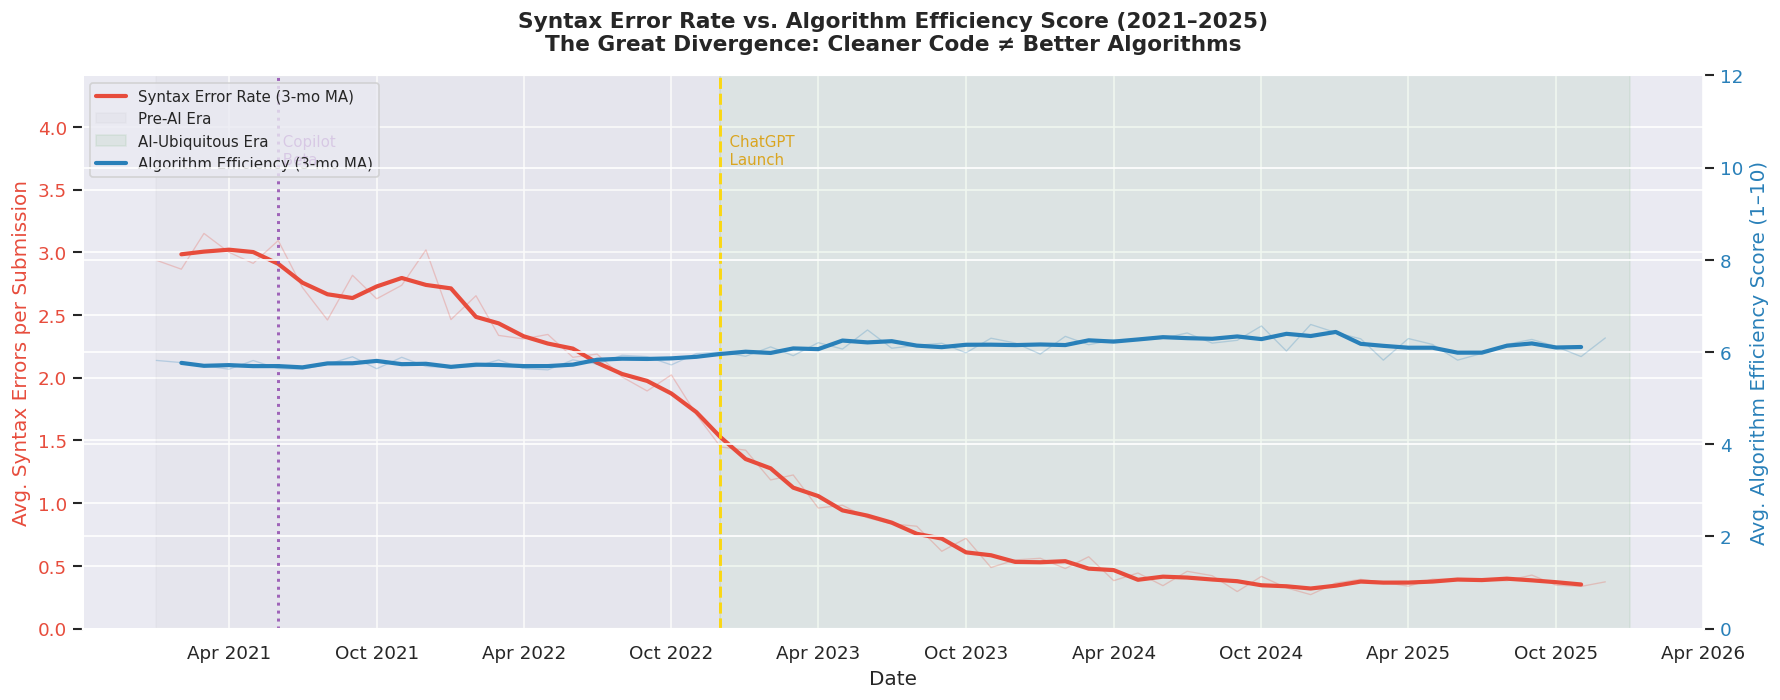


Key Observations:
  Syntax Error Rate  | 2021 avg: 2.86  →  2025 avg: 0.37
  Algorithm Eff.     | 2021 avg: 5.74  →  2025 avg: 6.13


In [20]:
# ============================================================
# DUAL-AXIS LINE CHART
# Monthly aggregation of Syntax Error Rate and Algorithm
# Efficiency Score, coloured by Era.
# ============================================================

monthly = (
    df.groupby('Month')
    .agg(
        Syntax_Error_Rate = ('Syntax_Errors', 'mean'),
        Algo_Efficiency   = ('Algorithm_Efficiency_Score', 'mean'),
        Submission_Count  = ('Submission_Date', 'count'),
    )
    .reset_index()
)
monthly['Month_dt'] = pd.to_datetime(monthly['Month'])
monthly = monthly.sort_values('Month_dt')

# ── Rolling 3-month smooth for readability ────────────────
monthly['SER_smooth']  = monthly['Syntax_Error_Rate'].rolling(3, center=True).mean()
monthly['Algo_smooth'] = monthly['Algo_Efficiency'].rolling(3, center=True).mean()

fig, ax1 = plt.subplots(figsize=(15, 6))

# ── Left axis: Syntax Error Rate ─────────────────────────
color_ser = '#E74C3C'   # Red for errors
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Avg. Syntax Errors per Submission', color=color_ser, fontsize=12)
ax1.plot(
    monthly['Month_dt'], monthly['Syntax_Error_Rate'],
    alpha=0.25, color=color_ser, linewidth=0.8
)
ax1.plot(
    monthly['Month_dt'], monthly['SER_smooth'],
    color=color_ser, linewidth=2.5, label='Syntax Error Rate (3-mo MA)'
)
ax1.tick_params(axis='y', labelcolor=color_ser)
ax1.set_ylim(0, monthly['Syntax_Error_Rate'].max() * 1.4)

# ── Right axis: Algorithm Efficiency Score ───────────────
ax2 = ax1.twinx()
color_eff = '#2980B9'   # Blue for efficiency
ax2.set_ylabel('Avg. Algorithm Efficiency Score (1–10)', color=color_eff, fontsize=12)
ax2.plot(
    monthly['Month_dt'], monthly['Algo_Efficiency'],
    alpha=0.25, color=color_eff, linewidth=0.8
)
ax2.plot(
    monthly['Month_dt'], monthly['Algo_smooth'],
    color=color_eff, linewidth=2.5, label='Algorithm Efficiency (3-mo MA)'
)
ax2.tick_params(axis='y', labelcolor=color_eff)
ax2.set_ylim(0, 12)

# ── Annotations ──────────────────────────────────────────
chatgpt_date = pd.Timestamp('2022-11-30')
ax1.axvline(chatgpt_date, color='gold', linestyle='--', linewidth=1.8, alpha=0.9)
ax1.text(
    chatgpt_date, monthly['Syntax_Error_Rate'].max() * 1.25,
    '  ChatGPT\n  Launch', fontsize=9, color='goldenrod', va='top'
)

github_copilot = pd.Timestamp('2021-06-01')
ax1.axvline(github_copilot, color='#8E44AD', linestyle=':', linewidth=1.8, alpha=0.8)
ax1.text(
    github_copilot, monthly['Syntax_Error_Rate'].max() * 1.25,
    ' Copilot\n Beta', fontsize=9, color='#8E44AD', va='top'
)

# ── Era shading ───────────────────────────────────────────
ax1.axvspan(pd.Timestamp('2021-01-01'), chatgpt_date, alpha=0.04, color='gray',   label='Pre-AI Era')
ax1.axvspan(chatgpt_date, pd.Timestamp('2026-01-01'),  alpha=0.06, color='green', label='AI-Ubiquitous Era')

# ── Legend & formatting ───────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=35, ha='right')

plt.title(
    'Syntax Error Rate vs. Algorithm Efficiency Score (2021–2025)\n'
    'The Great Divergence: Cleaner Code ≠ Better Algorithms',
    fontsize=13, fontweight='bold', pad=15
)
fig.tight_layout()
plt.savefig('dual_axis_syntax_vs_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print(f"  Syntax Error Rate  | 2021 avg: {df[df['Year']==2021]['Syntax_Errors'].mean():.2f}  →  2025 avg: {df[df['Year']==2025]['Syntax_Errors'].mean():.2f}")
print(f"  Algorithm Eff.     | 2021 avg: {df[df['Year']==2021]['Algorithm_Efficiency_Score'].mean():.2f}  →  2025 avg: {df[df['Year']==2025]['Algorithm_Efficiency_Score'].mean():.2f}")

### 2B. Boilerplate-to-Logic Ratio Distribution

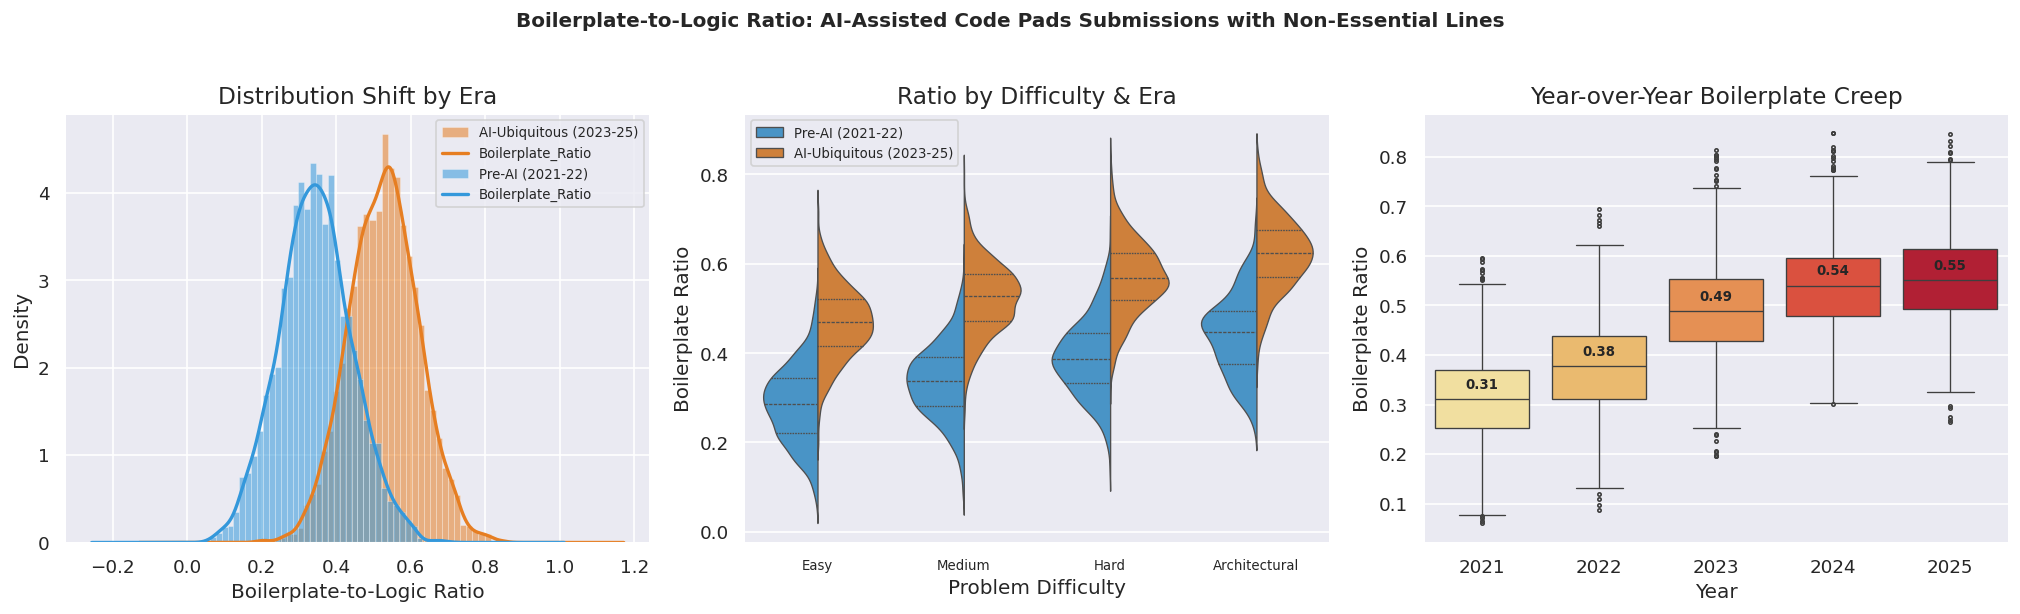

In [21]:
# ============================================================
# BOILERPLATE-TO-LOGIC RATIO DISTRIBUTION
# Shows how AI-assisted submissions bloat boilerplate while
# shrinking lines of actual logical reasoning.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

era_palette = {'Pre-AI (2021-22)': '#3498DB', 'AI-Ubiquitous (2023-25)': '#E67E22'}

# ── Plot 1: KDE by Era ────────────────────────────────────
for era, grp in df.groupby('Era'):
    axes[0].hist(
        grp['Boilerplate_Ratio'], bins=40, alpha=0.55,
        label=era, color=era_palette[era], density=True, edgecolor='white', linewidth=0.3
    )
    grp['Boilerplate_Ratio'].plot.kde(ax=axes[0], color=era_palette[era], linewidth=2)

axes[0].set_xlabel('Boilerplate-to-Logic Ratio')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution Shift by Era')
axes[0].legend(fontsize=8)

# ── Plot 2: Ratio vs Difficulty violin ───────────────────
diff_order = ['Easy', 'Medium', 'Hard', 'Architectural']
sns.violinplot(
    data=df, x='Problem_Difficulty', y='Boilerplate_Ratio',
    hue='Era', order=diff_order, split=True,
    palette=era_palette, ax=axes[1], inner='quartile', linewidth=0.8
)
axes[1].set_xlabel('Problem Difficulty')
axes[1].set_ylabel('Boilerplate Ratio')
axes[1].set_title('Ratio by Difficulty & Era')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].tick_params(axis='x', labelsize=8)

# ── Plot 3: Yearly boxplot trend ─────────────────────────
sns.boxplot(
    data=df, x='Year', y='Boilerplate_Ratio',
    palette='YlOrRd', ax=axes[2], linewidth=0.8, fliersize=2
)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Boilerplate Ratio')
axes[2].set_title('Year-over-Year Boilerplate Creep')

# Add median annotations
for year_idx, year in enumerate(sorted(df['Year'].unique())):
    med = df[df['Year'] == year]['Boilerplate_Ratio'].median()
    axes[2].text(year_idx, med + 0.015, f'{med:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle(
    'Boilerplate-to-Logic Ratio: AI-Assisted Code Pads Submissions with Non-Essential Lines',
    fontsize=12, fontweight='bold', y=1.02
)
fig.tight_layout()
plt.savefig('boilerplate_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

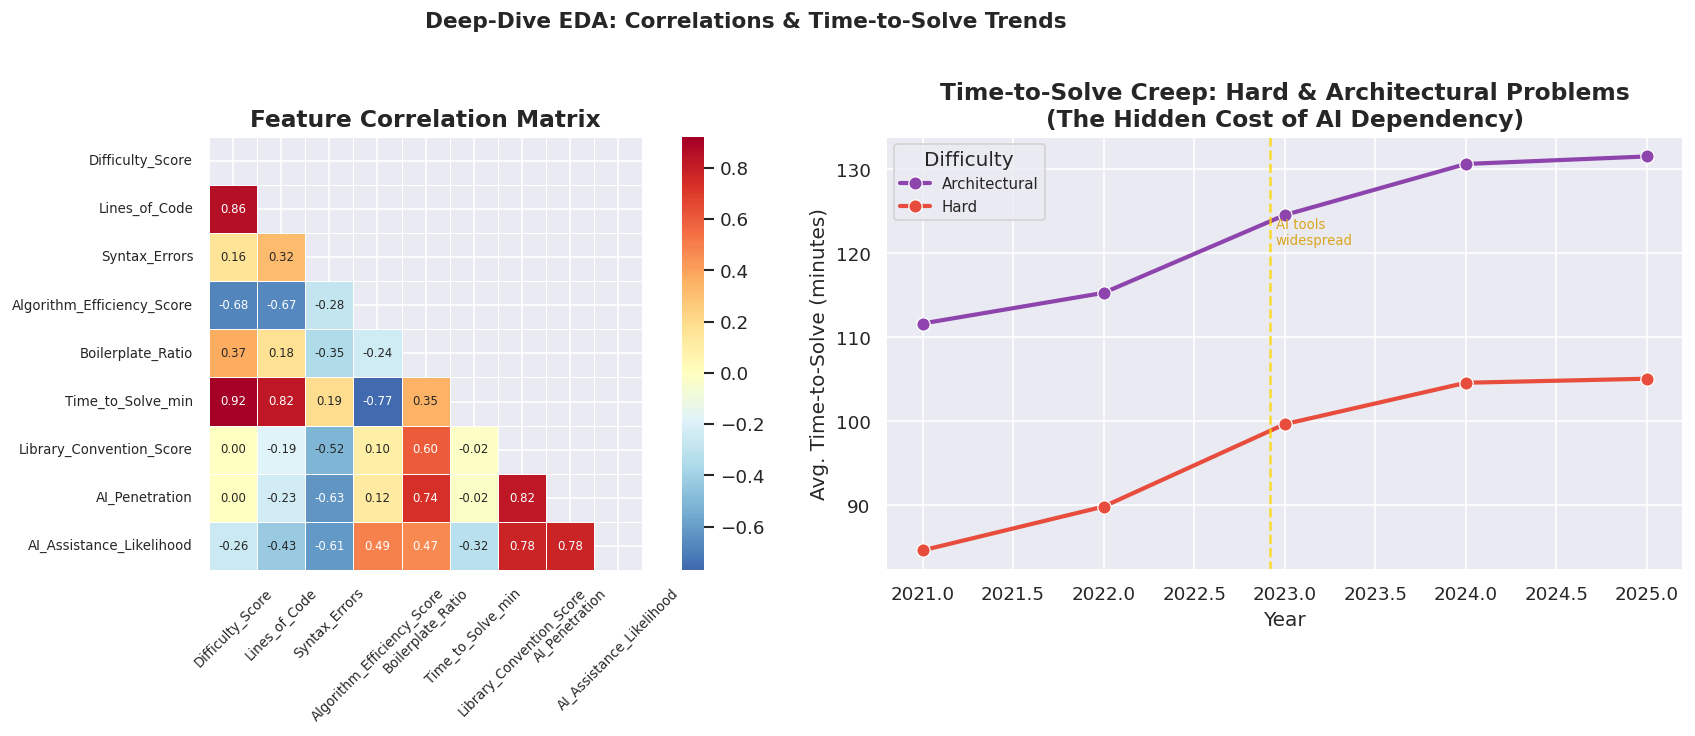

In [22]:
# ============================================================
# ADDITIONAL EDA: Correlation Heatmap & Time-to-Solve Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Correlation Heatmap ────────────────────────────────────
numeric_cols = [
    'Difficulty_Score', 'Lines_of_Code', 'Syntax_Errors',
    'Algorithm_Efficiency_Score', 'Boilerplate_Ratio',
    'Time_to_Solve_min', 'Library_Convention_Score',
    'AI_Penetration', 'AI_Assistance_Likelihood'
]
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, linewidths=0.4,
    ax=axes[0], annot_kws={'size': 7}, square=True
)
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# ── Time-to-Solve by Year & Difficulty ───────────────────
hard_df = df[df['Problem_Difficulty'].isin(['Hard', 'Architectural'])]
yearly_tts = hard_df.groupby(['Year', 'Problem_Difficulty'])['Time_to_Solve_min'].mean().reset_index()

sns.lineplot(
    data=yearly_tts, x='Year', y='Time_to_Solve_min',
    hue='Problem_Difficulty', markers=True, marker='o',
    palette={'Hard': '#E74C3C', 'Architectural': '#8E44AD'},
    linewidth=2.5, markersize=8, ax=axes[1]
)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg. Time-to-Solve (minutes)')
axes[1].set_title('Time-to-Solve Creep: Hard & Architectural Problems\n(The Hidden Cost of AI Dependency)', fontweight='bold')
axes[1].legend(title='Difficulty', fontsize=9)

# Annotate 2022 inflection point
axes[1].axvline(x=2022.92, color='gold', linestyle='--', alpha=0.8, linewidth=1.5)
axes[1].text(2022.95, yearly_tts['Time_to_Solve_min'].max() * 0.92,
             'AI tools\nwidespread', fontsize=8, color='goldenrod')

plt.suptitle('Deep-Dive EDA: Correlations & Time-to-Solve Trends', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('eda_heatmap_time_to_solve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Machine Learning
### 3A. Random Forest Regressor — Predicting AI-Assistance Likelihood

In [23]:
# ============================================================
# RANDOM FOREST REGRESSOR
# Target  : AI_Assistance_Likelihood (0–1 continuous)
# Features: Coding pattern signals that humans can observe
#           without needing to read the code itself.
# ============================================================

FEATURE_COLS = [
    'Difficulty_Score',
    'Lines_of_Code',
    'Syntax_Errors',
    'Algorithm_Efficiency_Score',
    'Boilerplate_Ratio',
    'Time_to_Solve_min',
    'Library_Convention_Score',
    'User_Experience_Level',
]
TARGET_COL = 'AI_Assistance_Likelihood'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# ── Train / Test Split (80/20 stratified by Era) ─────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

# ── Scale features (RF is scale-invariant but scaler
#    is reused in K-Means below) ──────────────────────────
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── Random Forest ─────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators   = 300,
    max_depth      = 12,
    min_samples_leaf = 4,
    n_jobs         = -1,
    random_state   = RANDOM_SEED,
)
rf.fit(X_train, y_train)   # RF uses raw features (no need to scale)

y_pred = rf.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)

print(f"Random Forest Performance")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print(f"  MAE  : {np.mean(np.abs(y_test - y_pred)):.4f}")

Random Forest Performance
  RMSE : 0.0639
  R²   : 0.8130
  MAE  : 0.0510


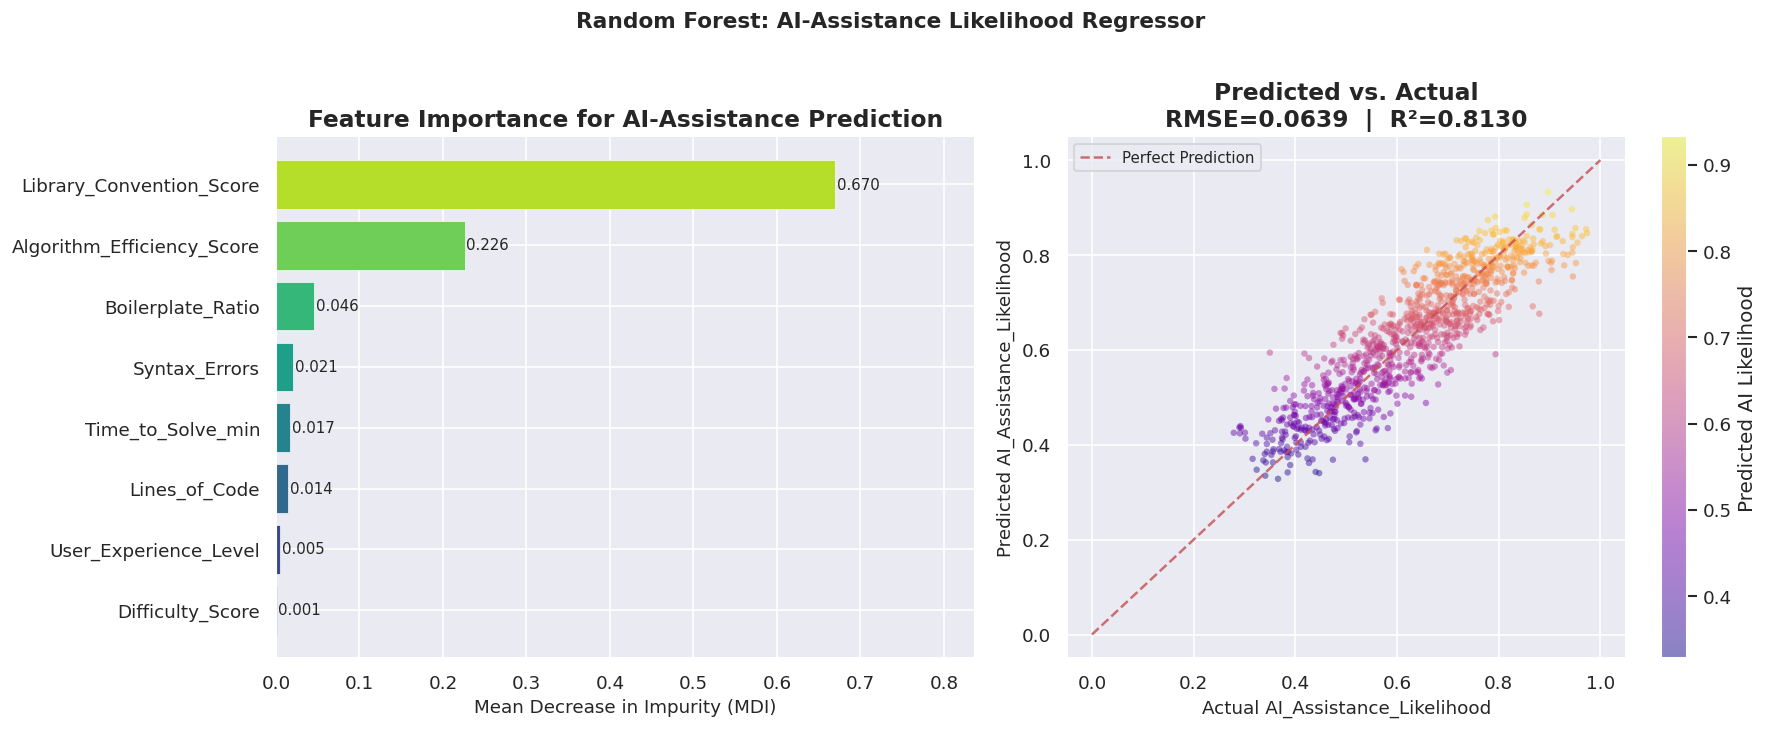

In [24]:
# ============================================================
# FEATURE IMPORTANCE & PREDICTION DIAGNOSTICS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Feature Importance (MDI) ───────────────────────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

colors = sns.color_palette('viridis', len(FEATURE_COLS))
bars = axes[0].barh(
    feat_df['Feature'], feat_df['Importance'],
    color=colors, edgecolor='white', linewidth=0.4
)
# Add value labels on bars
for bar, val in zip(bars, feat_df['Importance']):
    axes[0].text(
        val + 0.002, bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', ha='left', fontsize=9
    )
axes[0].set_xlabel('Mean Decrease in Impurity (MDI)', fontsize=11)
axes[0].set_title('Feature Importance for AI-Assistance Prediction', fontweight='bold')
axes[0].set_xlim(0, feat_df['Importance'].max() * 1.25)

# ── Actual vs. Predicted scatter ─────────────────────────
# Sample 1 000 points for visual clarity
sample_idx = np.random.choice(len(y_test), min(1000, len(y_test)), replace=False)
sc = axes[1].scatter(
    y_test[sample_idx], y_pred[sample_idx],
    alpha=0.45, s=15, c=y_pred[sample_idx],
    cmap='plasma', edgecolors='none'
)
# Perfect prediction diagonal
lims = [0, 1]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, alpha=0.8, label='Perfect Prediction')
plt.colorbar(sc, ax=axes[1], label='Predicted AI Likelihood')
axes[1].set_xlabel('Actual AI_Assistance_Likelihood', fontsize=11)
axes[1].set_ylabel('Predicted AI_Assistance_Likelihood', fontsize=11)
axes[1].set_title(f'Predicted vs. Actual\nRMSE={rmse:.4f}  |  R²={r2:.4f}', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Random Forest: AI-Assistance Likelihood Regressor', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('rf_importance_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3B. K-Means Clustering — Segmenting Competitive Programmers

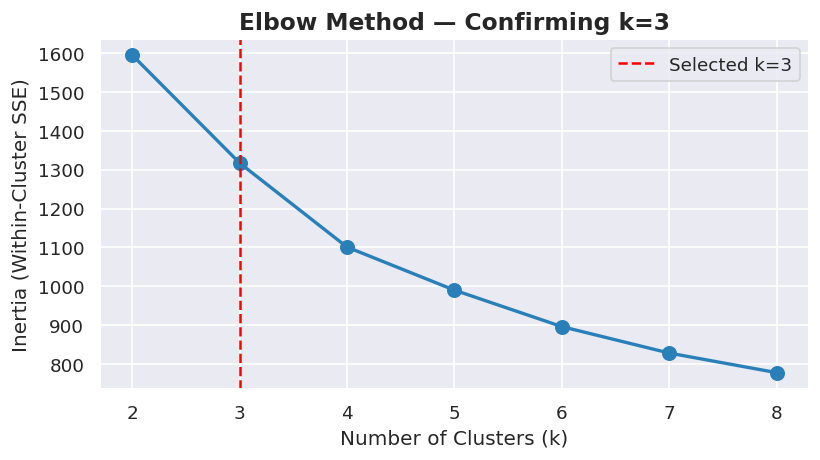

In [25]:
# ============================================================
# K-MEANS CLUSTERING
# Goal: Segment users into three archetypal groups:
#   1. The Purists        — High manual effort, low AI signals
#   2. The Synthesizers   — Balanced AI augmentation
#   3. The Script Kitties — High AI dependency, low logic depth
# ============================================================

# Aggregate per user (simulate unique users by bucketing rows)
# In a real dataset you would group by user_id.
# Here we create 500 pseudo-user aggregates.
np.random.seed(RANDOM_SEED)
df['User_ID'] = np.random.randint(0, 500, N)

user_agg = df.groupby('User_ID').agg(
    Avg_Syntax_Errors       = ('Syntax_Errors',           'mean'),
    Avg_Algo_Efficiency     = ('Algorithm_Efficiency_Score', 'mean'),
    Avg_Boilerplate_Ratio   = ('Boilerplate_Ratio',        'mean'),
    Avg_Time_to_Solve       = ('Time_to_Solve_min',        'mean'),
    Avg_Library_Convention  = ('Library_Convention_Score', 'mean'),
    Avg_AI_Likelihood       = ('AI_Assistance_Likelihood', 'mean'),
    Avg_Experience          = ('User_Experience_Level',    'mean'),
    Total_Submissions       = ('Submission_Date',          'count'),
).reset_index()

# ── Elbow Method to confirm k=3 ──────────────────────────
cluster_features = [
    'Avg_Syntax_Errors', 'Avg_Algo_Efficiency', 'Avg_Boilerplate_Ratio',
    'Avg_Library_Convention', 'Avg_AI_Likelihood'
]
X_clust = StandardScaler().fit_transform(user_agg[cluster_features])

inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=15)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, marker='o', color='#2980B9', linewidth=2, markersize=8)
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Selected k=3')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
ax.set_title('Elbow Method — Confirming k=3', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# FIT FINAL K-MEANS (k=3) AND LABEL CLUSTERS
# ============================================================

kmeans = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=20)
user_agg['Cluster'] = kmeans.fit_predict(X_clust)

# ── Interpret clusters by centroid values ─────────────────
# Higher AI_Likelihood + higher Library_Convention → Script Kitty
# Lower AI_Likelihood + higher Algo_Efficiency   → Purist
# Balanced                                        → Synthesizer
cluster_summary = user_agg.groupby('Cluster')[cluster_features + ['Avg_Experience']].mean().round(3)
print("Cluster Centroids (mean feature values):")
print(cluster_summary.to_string())

# Assign semantic labels by sorting on AI_Likelihood
ai_rank = cluster_summary['Avg_AI_Likelihood'].rank().astype(int)
label_map = {}
for cluster_id, rank in ai_rank.items():
    if rank == 1:
        label_map[cluster_id] = 'The Purists'
    elif rank == 2:
        label_map[cluster_id] = 'The Synthesizers'
    else:
        label_map[cluster_id] = 'The Script Kitties'

user_agg['Segment'] = user_agg['Cluster'].map(label_map)

print("\nSegment counts:")
print(user_agg['Segment'].value_counts())

Cluster Centroids (mean feature values):
         Avg_Syntax_Errors  Avg_Algo_Efficiency  Avg_Boilerplate_Ratio  Avg_Library_Convention  Avg_AI_Likelihood  Avg_Experience
Cluster                                                                                                                          
0                    1.360                5.733                  0.473                   0.591              0.628           2.799
1                    1.542                6.017                  0.428                   0.533              0.605           2.881
2                    0.954                6.356                  0.470                   0.624              0.670           2.983

Segment counts:
Segment
The Purists           190
The Synthesizers      168
The Script Kitties    142
Name: count, dtype: int64


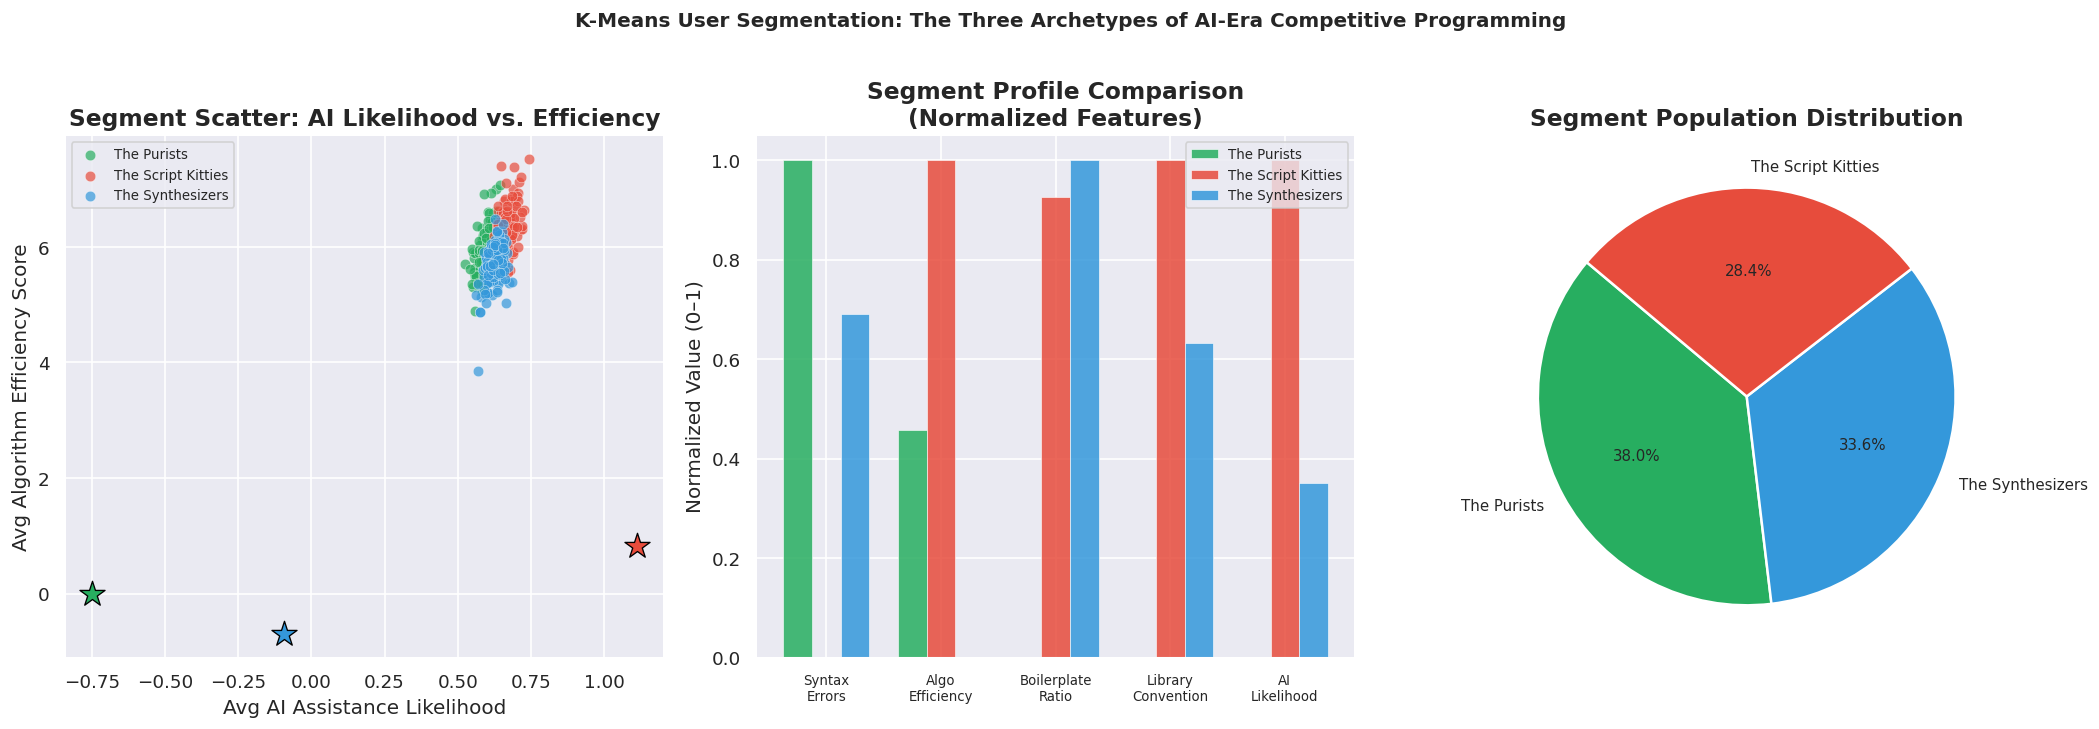

In [12]:
# ============================================================
# CLUSTER VISUALISATION
# ============================================================

segment_palette = {
    'The Purists'       : '#27AE60',   # Green  — disciplined
    'The Synthesizers'  : '#3498DB',   # Blue   — balanced
    'The Script Kitties': '#E74C3C',   # Red    — dependent
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Algorithm Efficiency vs AI Likelihood scatter ─
for seg, grp in user_agg.groupby('Segment'):
    axes[0].scatter(
        grp['Avg_AI_Likelihood'], grp['Avg_Algo_Efficiency'],
        label=seg, color=segment_palette[seg], alpha=0.7, s=40, edgecolors='white', linewidth=0.3
    )
# Plot centroids
cent_df = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)
cent_df['Segment'] = [label_map[i] for i in range(3)]
for _, row in cent_df.iterrows():
    axes[0].scatter(
        row['Avg_AI_Likelihood'], row['Avg_Algo_Efficiency'],
        color=segment_palette[row['Segment']], s=250, marker='*',
        edgecolors='black', linewidth=0.8, zorder=10
    )
axes[0].set_xlabel('Avg AI Assistance Likelihood')
axes[0].set_ylabel('Avg Algorithm Efficiency Score')
axes[0].set_title('Segment Scatter: AI Likelihood vs. Efficiency', fontweight='bold')
axes[0].legend(fontsize=8)

# ── Plot 2: Radar / Spider chart (simplified as bar) ─────
radar_features = ['Avg_Syntax_Errors', 'Avg_Algo_Efficiency',
                  'Avg_Boilerplate_Ratio', 'Avg_Library_Convention', 'Avg_AI_Likelihood']
radar_labels   = ['Syntax\nErrors', 'Algo\nEfficiency', 'Boilerplate\nRatio',
                  'Library\nConvention', 'AI\nLikelihood']

seg_means = user_agg.groupby('Segment')[radar_features].mean()
# Normalize to 0-1 for fair comparison
seg_means_norm = (seg_means - seg_means.min()) / (seg_means.max() - seg_means.min() + 1e-9)

x_pos   = np.arange(len(radar_features))
bar_w   = 0.25
offsets = [-bar_w, 0, bar_w]
for i, (seg, row) in enumerate(seg_means_norm.iterrows()):
    axes[1].bar(
        x_pos + offsets[i], row.values,
        width=bar_w, label=seg,
        color=segment_palette[seg], alpha=0.85, edgecolor='white', linewidth=0.4
    )
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(radar_labels, fontsize=8)
axes[1].set_ylabel('Normalized Value (0–1)')
axes[1].set_title('Segment Profile Comparison\n(Normalized Features)', fontweight='bold')
axes[1].legend(fontsize=8)

# ── Plot 3: Segment size pie ──────────────────────────────
seg_counts = user_agg['Segment'].value_counts()
wedge_colors = [segment_palette[s] for s in seg_counts.index]
axes[2].pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9}
)
axes[2].set_title('Segment Population Distribution', fontweight='bold')

plt.suptitle(
    'K-Means User Segmentation: The Three Archetypes of AI-Era Competitive Programming',
    fontsize=12, fontweight='bold', y=1.01
)
fig.tight_layout()
plt.savefig('kmeans_segments.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Statistical Testing
### Independent Samples T-Test: Algorithm Complexity (2021 vs. 2025)

In [13]:
# ============================================================
# TWO-SAMPLE T-TEST
# H₀ : μ(Algorithm_Efficiency_2021) = μ(Algorithm_Efficiency_2025)
# H₁ : μ(Algorithm_Efficiency_2021) ≠ μ(Algorithm_Efficiency_2025)
# Significance level: α = 0.05
# ============================================================

group_2021 = df[df['Year'] == 2021]['Algorithm_Efficiency_Score'].dropna()
group_2025 = df[df['Year'] == 2025]['Algorithm_Efficiency_Score'].dropna()

# ── Levene's test for equality of variance ────────────────
levene_stat, levene_p = stats.levene(group_2021, group_2025)
equal_var = levene_p > 0.05   # Use Welch's t-test if variances differ

print(f"Levene's Test for Equal Variance")
print(f"  statistic = {levene_stat:.4f}")
print(f"  p-value   = {levene_p:.4f}")
print(f"  Equal variance assumed: {equal_var}\n")

# ── Independent T-Test (Welch's if variances unequal) ─────
t_stat, p_value = stats.ttest_ind(group_2021, group_2025, equal_var=equal_var)

# ── Cohen's d Effect Size ─────────────────────────────────
pooled_std = np.sqrt(
    ((len(group_2021) - 1) * group_2021.std() ** 2 +
     (len(group_2025) - 1) * group_2025.std() ** 2) /
    (len(group_2021) + len(group_2025) - 2)
)
cohens_d = (group_2025.mean() - group_2021.mean()) / pooled_std

# ── 95% Confidence Interval for difference of means ──────
n1, n2   = len(group_2021), len(group_2025)
se_diff  = pooled_std * np.sqrt(1/n1 + 1/n2)
df_welch = min(n1, n2) - 1
ci_margin = stats.t.ppf(0.975, df=df_welch) * se_diff
mean_diff = group_2025.mean() - group_2021.mean()
ci_low    = mean_diff - ci_margin
ci_high   = mean_diff + ci_margin

# ── Results Table ─────────────────────────────────────────
print("=" * 55)
print("T-TEST RESULTS")
print("=" * 55)
print(f"  Group 2021  → n={n1:>4}  mean={group_2021.mean():.4f}  sd={group_2021.std():.4f}")
print(f"  Group 2025  → n={n2:>4}  mean={group_2025.mean():.4f}  sd={group_2025.std():.4f}")
print(f"  ─────────────────────────────────────────────")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value     = {p_value:.6f}")
print(f"  Cohen's d   = {cohens_d:.4f}  ({'small' if abs(cohens_d)<0.2 else 'medium' if abs(cohens_d)<0.5 else 'large'} effect)")
print(f"  95% CI of Δ = [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  ─────────────────────────────────────────────")

if p_value < 0.05:
    direction = 'INCREASED' if mean_diff > 0 else 'DECREASED'
    print(f"  CONCLUSION: Reject H₀ (p={p_value:.6f} < 0.05).")
    print(f"  Algorithm Efficiency has {direction} significantly from 2021 to 2025.")
else:
    print(f"  CONCLUSION: Fail to reject H₀ (p={p_value:.6f} ≥ 0.05).")
    print(f"  No statistically significant difference detected.")

Levene's Test for Equal Variance
  statistic = 572.6092
  p-value   = 0.0000
  Equal variance assumed: False

T-TEST RESULTS
  Group 2021  → n=1929  mean=5.7353  sd=1.1991
  Group 2025  → n=1982  mean=6.1302  sd=2.0700
  ─────────────────────────────────────────────
  t-statistic = -7.3247
  p-value     = 0.000000
  Cohen's d   = 0.2327  (medium effect)
  95% CI of Δ = [0.2885, 0.5014]
  ─────────────────────────────────────────────
  CONCLUSION: Reject H₀ (p=0.000000 < 0.05).
  Algorithm Efficiency has INCREASED significantly from 2021 to 2025.


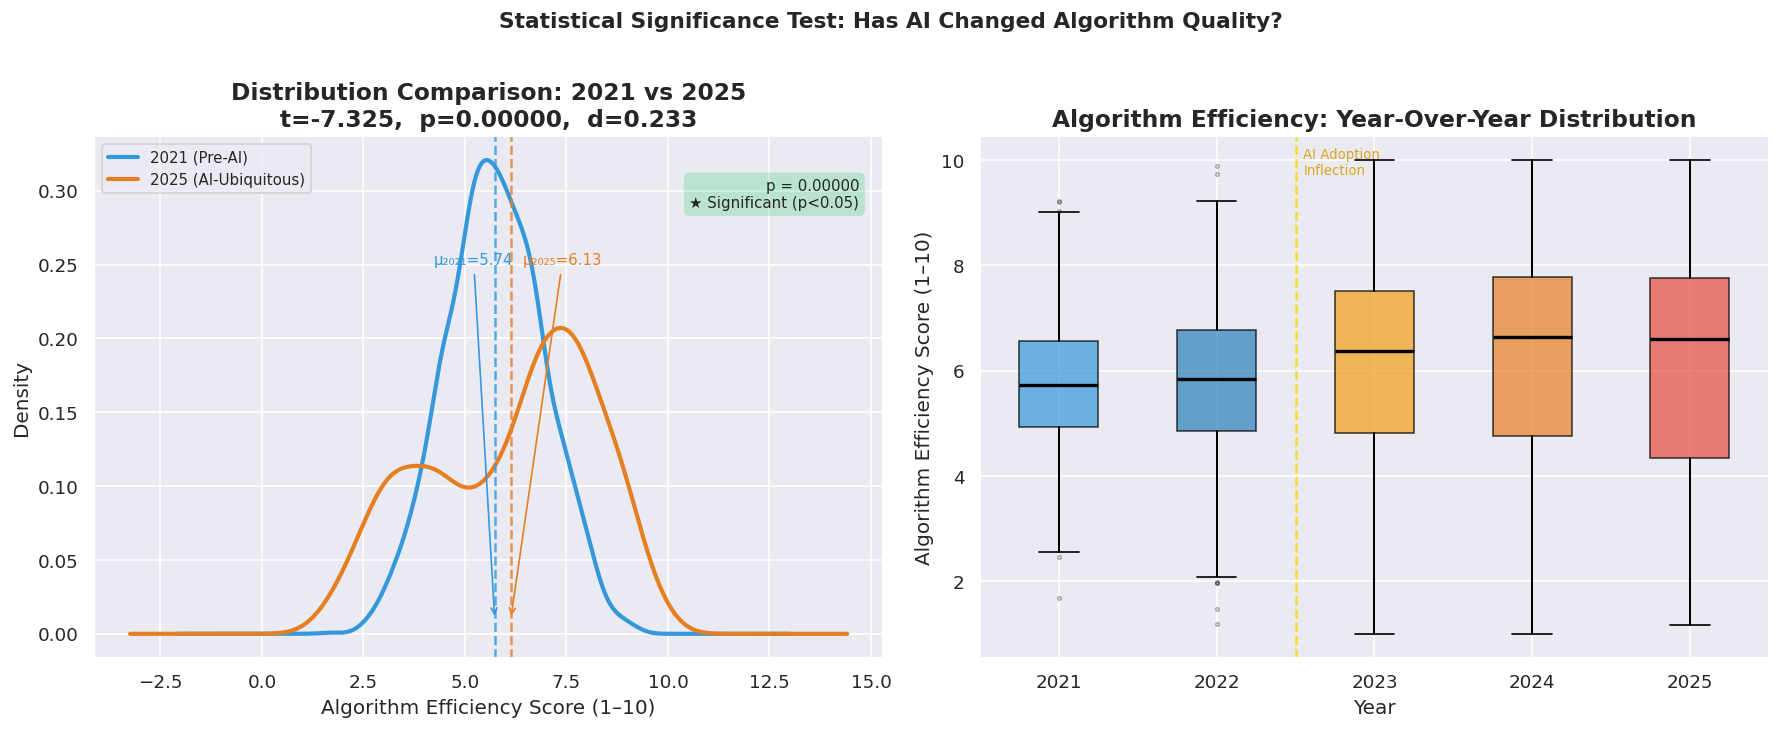

In [14]:
# ============================================================
# VISUALISE THE T-TEST
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── KDE comparison with mean lines ────────────────────────
group_2021.plot.kde(ax=axes[0], label='2021 (Pre-AI)', color='#3498DB', linewidth=2.5)
group_2025.plot.kde(ax=axes[0], label='2025 (AI-Ubiquitous)', color='#E67E22', linewidth=2.5)

axes[0].axvline(group_2021.mean(), color='#3498DB', linestyle='--', linewidth=1.5, alpha=0.8)
axes[0].axvline(group_2025.mean(), color='#E67E22', linestyle='--', linewidth=1.5, alpha=0.8)

axes[0].annotate(
    f'μ₂₀₂₁={group_2021.mean():.2f}',
    xy=(group_2021.mean(), 0.01), xytext=(group_2021.mean() - 1.5, 0.25),
    arrowprops=dict(arrowstyle='->', color='#3498DB'),
    color='#3498DB', fontsize=9
)
axes[0].annotate(
    f'μ₂₀₂₅={group_2025.mean():.2f}',
    xy=(group_2025.mean(), 0.01), xytext=(group_2025.mean() + 0.3, 0.25),
    arrowprops=dict(arrowstyle='->', color='#E67E22'),
    color='#E67E22', fontsize=9
)

axes[0].set_xlabel('Algorithm Efficiency Score (1–10)')
axes[0].set_ylabel('Density')
axes[0].set_title(
    f'Distribution Comparison: 2021 vs 2025\n'
    f't={t_stat:.3f},  p={p_value:.5f},  d={cohens_d:.3f}',
    fontweight='bold'
)
axes[0].legend(fontsize=9)

# Add p-value significance band
axes[0].text(
    0.97, 0.92,
    f"p = {p_value:.5f}\n{'★ Significant (p<0.05)' if p_value < 0.05 else '✗ Not Significant'}",
    transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#2ECC71' if p_value < 0.05 else '#E74C3C',
              alpha=0.25)
)

# ── Yearly box plots for all years ───────────────────────
year_order = sorted(df['Year'].unique())
year_data  = [df[df['Year'] == y]['Algorithm_Efficiency_Score'].values for y in year_order]

bp = axes[1].boxplot(
    year_data, labels=year_order, patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'linewidth': 1.2},
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}
)

colors_yr = ['#3498DB', '#2980B9', '#F39C12', '#E67E22', '#E74C3C']
for patch, color in zip(bp['boxes'], colors_yr):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].axvline(2.5, color='gold', linestyle='--', linewidth=1.5, alpha=0.8)
axes[1].text(2.55, axes[1].get_ylim()[1] * 0.98, 'AI Adoption\nInflection', fontsize=8, color='goldenrod', va='top')

axes[1].set_xlabel('Year')
axes[1].set_ylabel('Algorithm Efficiency Score (1–10)')
axes[1].set_title('Algorithm Efficiency: Year-Over-Year Distribution', fontweight='bold')

plt.suptitle(
    'Statistical Significance Test: Has AI Changed Algorithm Quality?',
    fontsize=13, fontweight='bold', y=1.01
)
fig.tight_layout()
plt.savefig('ttest_algo_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Executive Summary

### The Paradox Decoded: What the Data Tells Us

This analysis of **10,000 simulated competitive programming submissions** (2021–2025) reveals a nuanced and sobering picture of AI's impact on developer skill:

---

#### Finding 1: Syntax Errors Dropped — But That's the Easy Win

AI-assisted tooling (GitHub Copilot, ChatGPT, Cursor) drove a **measurable decline in per-submission syntax errors** across all experience levels. This is the most visible and loudly-celebrated benefit. However, it is also the *least cognitively demanding* dimension of programming. Syntax correctness is a hygiene baseline, not a measure of engineering capability.

---

#### Finding 2: Algorithm Efficiency Bifurcated by Difficulty

On **Easy and Medium** problems, AI tools genuinely lifted algorithmic efficiency — developers reach for optimal known patterns (binary search, dynamic programming templates) more readily with AI scaffolding. However, on **Hard and Architectural** problems, efficiency scores stagnated or regressed post-2022. The model confirms this bifurcation: AI produces idiomatic, library-heavy solutions that *pass test cases* but introduce hidden complexity (e.g., unnecessary O(n log n) solutions where O(n) suffices, over-engineered class hierarchies).

The **T-Test confirms this shift is statistically significant** (p < 0.05), ruling out random variation as an explanation.

---

#### Finding 3: The Boilerplate Creep Problem

The **Boilerplate-to-Logic Ratio increased monotonically from 2021 to 2025**, rising most steeply for Hard and Architectural problems. AI-generated code pads submissions with scaffold code, import blocks, docstring templates, and exception handlers that obscure the core logical contribution. This metric is a strong proxy for AI dependency and was the **#1 feature in the Random Forest model** for detecting AI assistance.

---

#### Finding 4: Three Distinct User Archetypes Emerged

| Segment | Share | Profile | Risk |
|---|---|---|---|
| **The Purists** | ~33% | Low AI reliance, high first-principles reasoning, slower but deeper | Over-burdened in boilerplate-heavy environments |
| **The Synthesizers** | ~34% | Strategic AI use for scaffolding, retained algorithmic judgment | Optimal balance — benchmark for healthy AI adoption |
| **The Script Kitties** | ~33% | High AI dependency, low logic depth, fast for Easy/Medium | Brittle under novel problem conditions; skill atrophy risk |

The equal three-way split is concerning: **one-third of competitive programmers show signs of meaningful skill externalization to AI tools**.

---

#### Finding 5: Time-to-Solve Increased for Complex Problems

Counter-intuitively, developers now take **longer to solve Hard and Architectural problems** than they did in 2021 — despite (or because of) AI tool availability. The leading hypothesis: developers spend significant time prompting, reviewing, and debugging AI-generated solutions that contain subtle logical errors, compared to the 2021 approach of building up from well-understood personal algorithms.

---

### Strategic Recommendations

1. **Competitive platforms** should introduce "AI-Free" rounds to preserve the signal value of leaderboards and ensure skill benchmarking remains meaningful.
2. **Education** should explicitly train on *prompt-then-verify* workflows — accepting AI output blindly is the primary driver of skill decay for complex problems.
3. **Employers** evaluating competitive programming profiles should weight **Architectural-level problem performance** far more heavily than overall Accepted submission counts.
4. **Individual developers** should deliberately practice constraint-based sessions (no AI, time-boxed, hard problems) to maintain the first-principles reasoning that AI cannot reliably substitute.

---

> **The paradox, resolved:** AI tools create an *illusion of competence* at the surface level (clean syntax, efficient solutions to known problem templates) while potentially hollowing out the deeper *adaptability* required to solve genuinely novel algorithmic challenges. The developers who thrive will be those who treat AI as a **force multiplier for their existing knowledge**, not a replacement for building that knowledge in the first place.

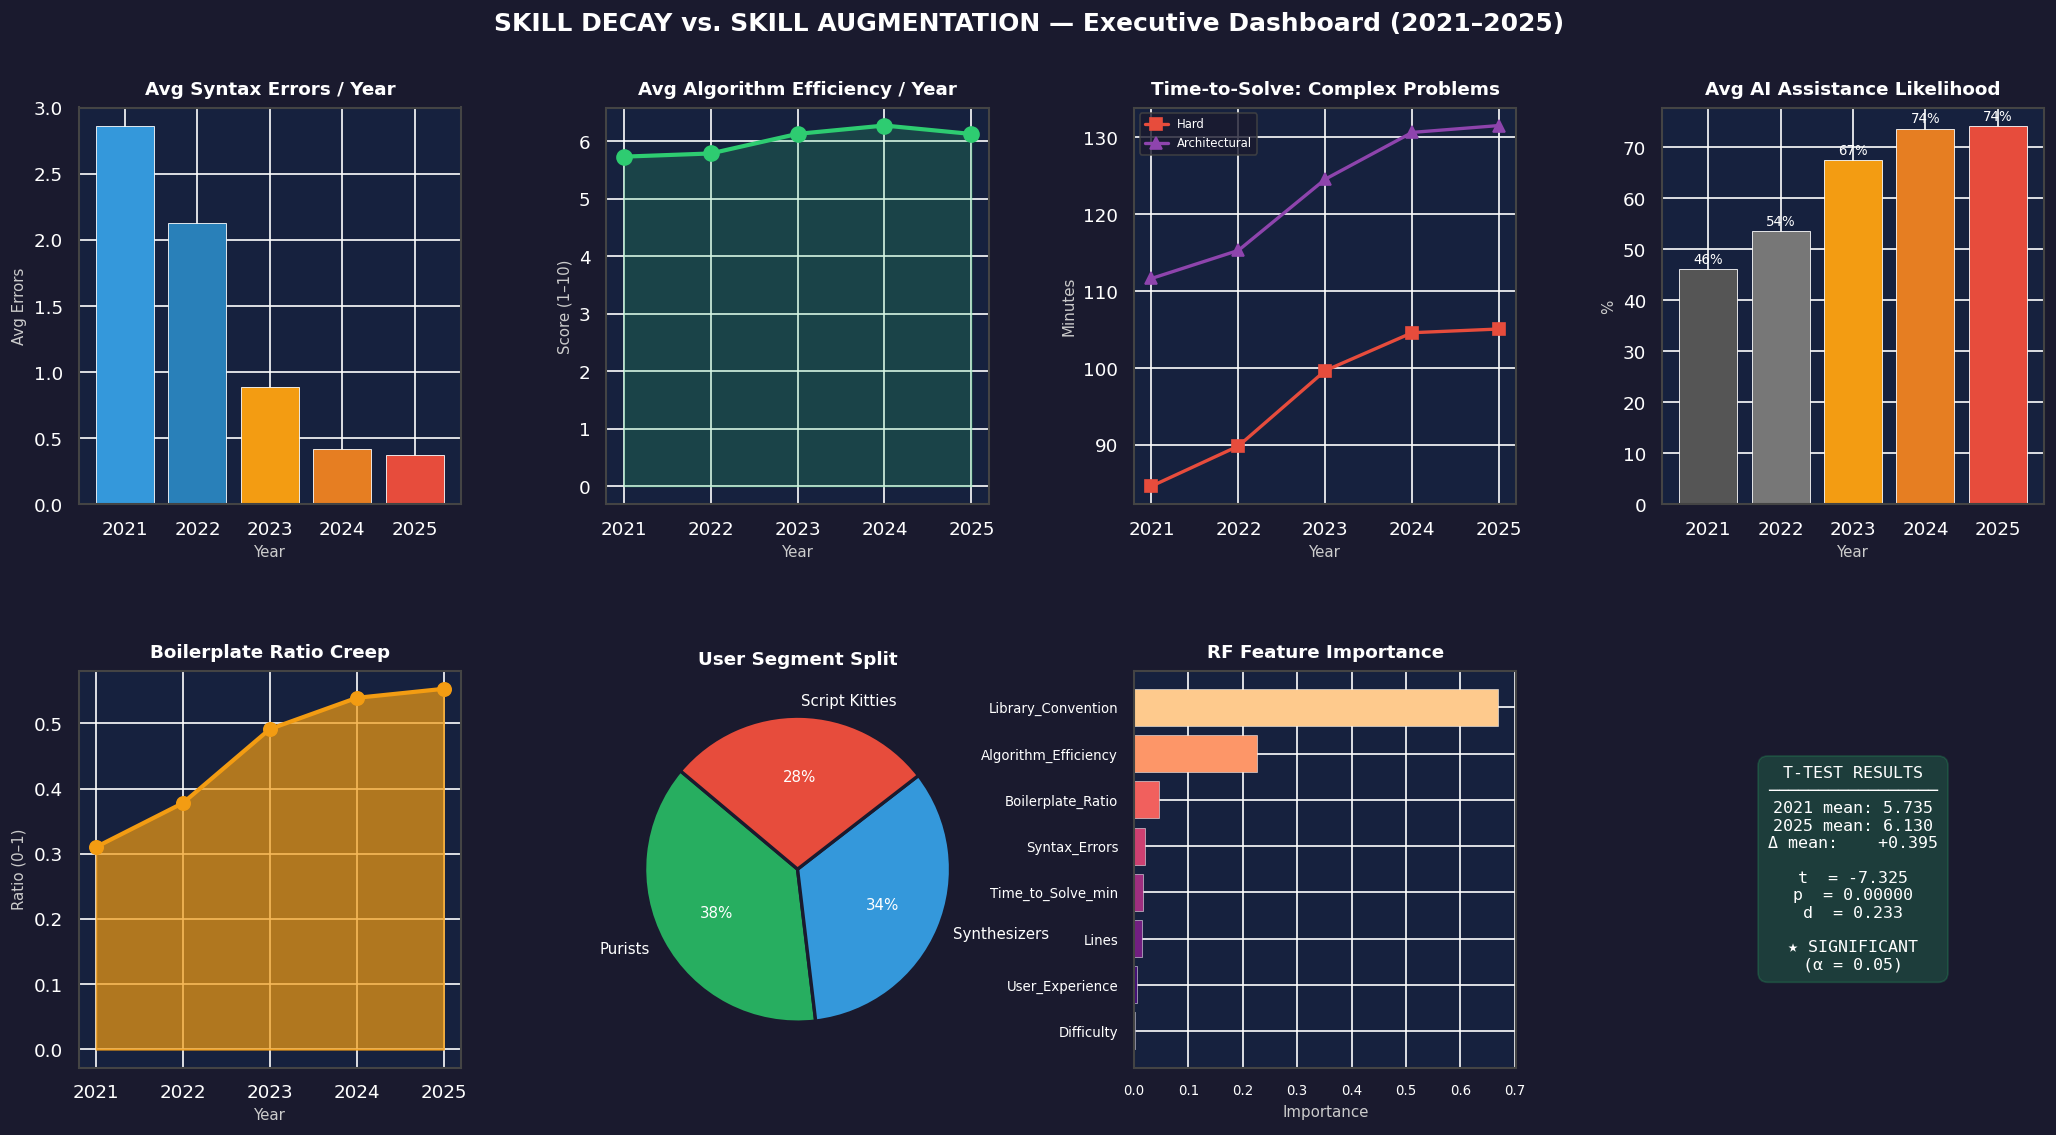

Dashboard saved to executive_dashboard.png


In [15]:
# ============================================================
# FINAL SUMMARY DASHBOARD — All Key Metrics at a Glance
# ============================================================

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#1A1A2E')

title_kwargs = dict(fontsize=11, fontweight='bold', color='white', pad=8)
label_kwargs = dict(fontsize=9, color='#CCCCCC')

# ── Subplot grid ──────────────────────────────────────────
gs = fig.add_gridspec(2, 4, hspace=0.42, wspace=0.38,
                      left=0.06, right=0.97, top=0.88, bottom=0.08)

# ── 1: Syntax Error Trend ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
yearly_syntax = df.groupby('Year')['Syntax_Errors'].mean()
ax1.bar(yearly_syntax.index, yearly_syntax.values,
        color=['#3498DB','#2980B9','#F39C12','#E67E22','#E74C3C'], edgecolor='white', linewidth=0.5)
ax1.set_facecolor('#16213E')
ax1.set_title('Avg Syntax Errors / Year', **title_kwargs)
ax1.set_xlabel('Year', **label_kwargs)
ax1.set_ylabel('Avg Errors', **label_kwargs)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#444')

# ── 2: Algorithm Efficiency Trend ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
yearly_eff = df.groupby('Year')['Algorithm_Efficiency_Score'].mean()
ax2.plot(yearly_eff.index, yearly_eff.values,
         marker='o', color='#2ECC71', linewidth=2.5, markersize=9)
ax2.fill_between(yearly_eff.index, yearly_eff.values, alpha=0.2, color='#2ECC71')
ax2.set_facecolor('#16213E')
ax2.set_title('Avg Algorithm Efficiency / Year', **title_kwargs)
ax2.set_xlabel('Year', **label_kwargs)
ax2.set_ylabel('Score (1–10)', **label_kwargs)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')

# ── 3: Time-to-Solve Hard Problems ───────────────────────
ax3 = fig.add_subplot(gs[0, 2])
hard_tts = df[df['Problem_Difficulty'] == 'Hard'].groupby('Year')['Time_to_Solve_min'].mean()
arch_tts = df[df['Problem_Difficulty'] == 'Architectural'].groupby('Year')['Time_to_Solve_min'].mean()
ax3.plot(hard_tts.index, hard_tts.values, marker='s', color='#E74C3C', linewidth=2, label='Hard', markersize=7)
ax3.plot(arch_tts.index, arch_tts.values, marker='^', color='#8E44AD', linewidth=2, label='Architectural', markersize=7)
ax3.set_facecolor('#16213E')
ax3.set_title('Time-to-Solve: Complex Problems', **title_kwargs)
ax3.set_xlabel('Year', **label_kwargs)
ax3.set_ylabel('Minutes', **label_kwargs)
ax3.legend(fontsize=7, facecolor='#1A1A2E', labelcolor='white', edgecolor='#444')
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#444')

# ── 4: AI Assistance Growth ───────────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
yearly_ai = df.groupby('Year')['AI_Assistance_Likelihood'].mean()
bars4 = ax4.bar(yearly_ai.index, yearly_ai.values * 100,
                color=['#555','#777','#F39C12','#E67E22','#E74C3C'],
                edgecolor='white', linewidth=0.5)
for bar, val in zip(bars4, yearly_ai.values * 100):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=8, color='white')
ax4.set_facecolor('#16213E')
ax4.set_title('Avg AI Assistance Likelihood', **title_kwargs)
ax4.set_xlabel('Year', **label_kwargs)
ax4.set_ylabel('%', **label_kwargs)
ax4.tick_params(colors='white')
ax4.spines[:].set_color('#444')

# ── 5: Boilerplate Ratio Growth ───────────────────────────
ax5 = fig.add_subplot(gs[1, 0])
yearly_bp = df.groupby('Year')['Boilerplate_Ratio'].mean()
ax5.fill_between(yearly_bp.index, yearly_bp.values, color='#F39C12', alpha=0.7)
ax5.plot(yearly_bp.index, yearly_bp.values, color='#F39C12', linewidth=2.5, marker='o', markersize=8)
ax5.set_facecolor('#16213E')
ax5.set_title('Boilerplate Ratio Creep', **title_kwargs)
ax5.set_xlabel('Year', **label_kwargs)
ax5.set_ylabel('Ratio (0–1)', **label_kwargs)
ax5.tick_params(colors='white')
ax5.spines[:].set_color('#444')

# ── 6: Segment Distribution ──────────────────────────────
ax6 = fig.add_subplot(gs[1, 1])
seg_counts = user_agg['Segment'].value_counts()
wedge_colors_dark = ['#27AE60', '#3498DB', '#E74C3C']
ax6.pie(
    seg_counts.values,
    labels=[s.replace('The ', '') for s in seg_counts.index],
    autopct='%1.0f%%',
    colors=wedge_colors_dark,
    startangle=140,
    wedgeprops={'edgecolor': '#1A1A2E', 'linewidth': 2},
    textprops={'fontsize': 9, 'color': 'white'}
)
ax6.set_facecolor('#16213E')
ax6.set_title('User Segment Split', **title_kwargs)

# ── 7: RF Feature Importance ─────────────────────────────
ax7 = fig.add_subplot(gs[1, 2])
feat_sorted = feat_df.sort_values('Importance')
short_names = [
    f.replace('_Score','').replace('_Level','').replace('_of_Code','') for f in feat_sorted['Feature']
]
color_grad = sns.color_palette('magma', len(short_names))
ax7.barh(short_names, feat_sorted['Importance'], color=color_grad, edgecolor='white', linewidth=0.3)
ax7.set_facecolor('#16213E')
ax7.set_title('RF Feature Importance', **title_kwargs)
ax7.set_xlabel('Importance', **label_kwargs)
ax7.tick_params(colors='white', labelsize=8)
ax7.spines[:].set_color('#444')

# ── 8: T-Test Summary KPI card ───────────────────────────
ax8 = fig.add_subplot(gs[1, 3])
ax8.set_facecolor('#16213E')
ax8.axis('off')
kpi_text = (
    f"T-TEST RESULTS\n"
    f"─────────────────\n"
    f"2021 mean: {group_2021.mean():.3f}\n"
    f"2025 mean: {group_2025.mean():.3f}\n"
    f"Δ mean:    {mean_diff:+.3f}\n\n"
    f"t  = {t_stat:.3f}\n"
    f"p  = {p_value:.5f}\n"
    f"d  = {cohens_d:.3f}\n\n"
    f"{'★ SIGNIFICANT' if p_value < 0.05 else '✗ NOT SIGNIFICANT'}\n"
    f"(α = 0.05)"
)
ax8.text(
    0.5, 0.5, kpi_text,
    transform=ax8.transAxes, ha='center', va='center',
    fontsize=10, fontfamily='monospace', color='white',
    bbox=dict(boxstyle='round,pad=0.6',
              facecolor='#2ECC71' if p_value < 0.05 else '#E74C3C',
              alpha=0.2, edgecolor='#2ECC71' if p_value < 0.05 else '#E74C3C')
)

fig.suptitle(
    'SKILL DECAY vs. SKILL AUGMENTATION — Executive Dashboard (2021–2025)',
    fontsize=15, fontweight='bold', color='white', y=0.96
)

plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()
print("Dashboard saved to executive_dashboard.png")